In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


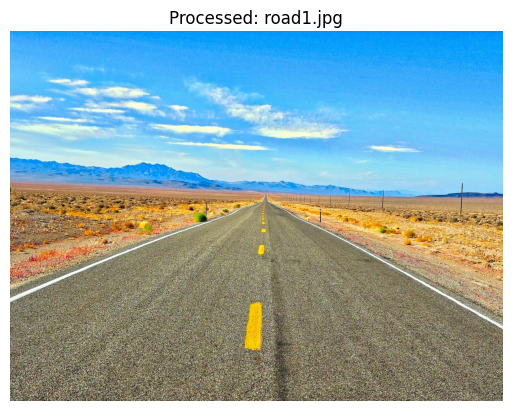

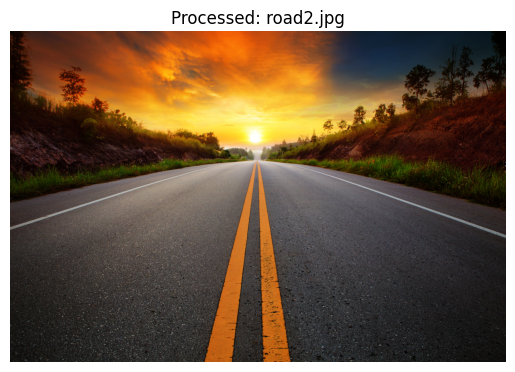

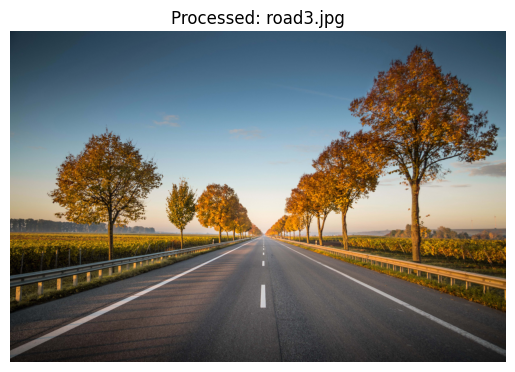

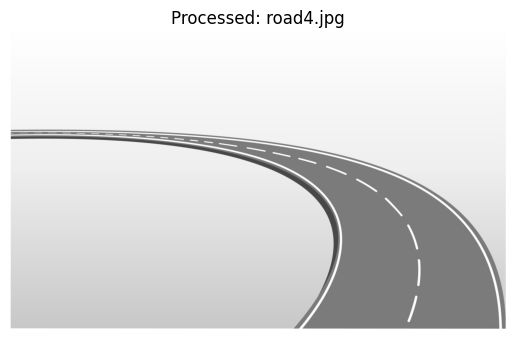

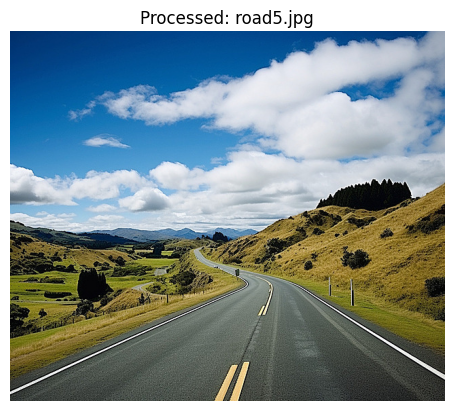

In [ ]:
image_files = ['road1.jpg', 'road2.jpg', 'road3.jpg', 'road4.jpg','road5.jpg']  # your image file names

for file in image_files:
    image = cv2.imread(file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)



    plt.imshow(image)
    plt.title(f"Processed: {file}")
    plt.axis("off")
    plt.show()    



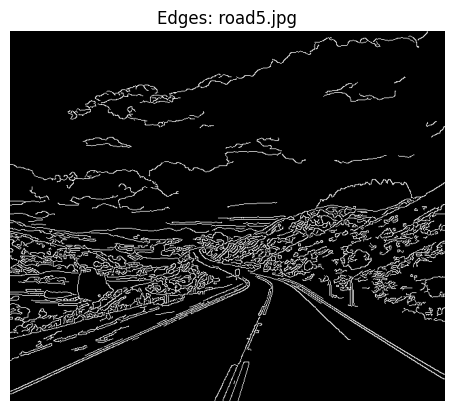

In [3]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Apply Gaussian Blur
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply Canny Edge Detection
edges = cv2.Canny(blur, threshold1=50, threshold2=150)

# Show edges
plt.imshow(edges, cmap='gray')
plt.title(f"Edges: {file}")
plt.axis("off")
plt.show()


In [ ]:
import numpy as np

def region_of_interest(image):
    height = image.shape[0]
    width = image.shape[1]

   
    polygons = np.array([
        [(100, height), (width - 100, height), (width // 2, height // 2)]
    ])

    mask = np.zeros_like(image)
    cv2.fillPoly(mask, polygons, 255)
    
    # Apply the mask
    masked_image = cv2.bitwise_and(image, mask)
    return masked_image



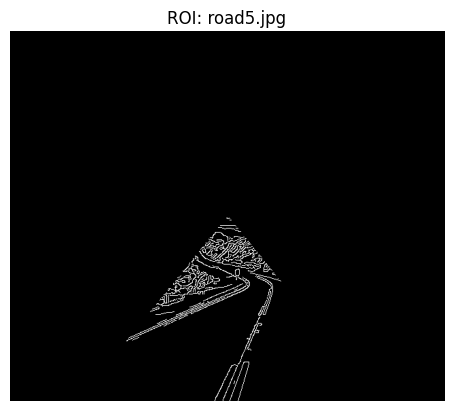

In [5]:
roi = region_of_interest(edges)

# Show masked edge image
plt.imshow(roi, cmap='gray')
plt.title(f"ROI: {file}")
plt.axis("off")
plt.show()


In [6]:
def detect_lines(image):
    # Hough transform parameters
    return cv2.HoughLinesP(
        image,
        rho=2,
        theta=np.pi / 180,
        threshold=100,
        minLineLength=40,
        maxLineGap=5
    )


In [7]:
def draw_lines(image, lines):
    line_image = np.zeros_like(image)
    
    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 5)

    # Combine original image with line image
    combined = cv2.addWeighted(image, 0.8, line_image, 1, 1)
    return combined



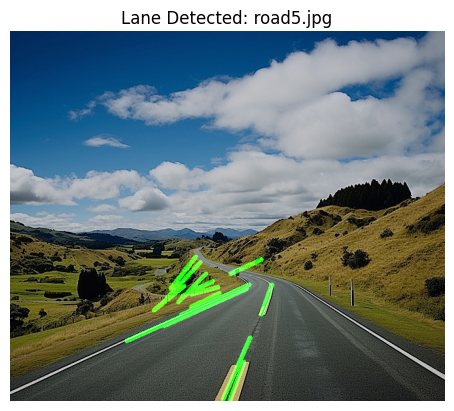

In [8]:
lines = detect_lines(roi)
line_image = draw_lines(image, lines)

plt.imshow(line_image)
plt.title(f"Lane Detected: {file}")
plt.axis("off")
plt.show()


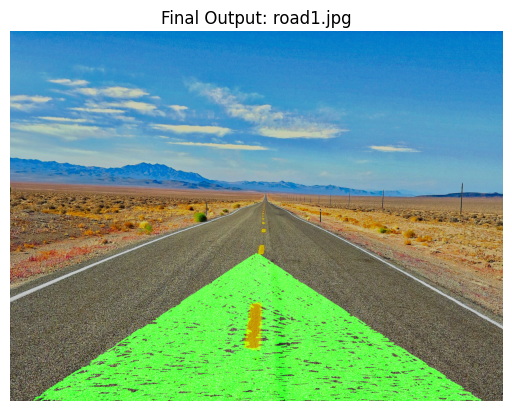

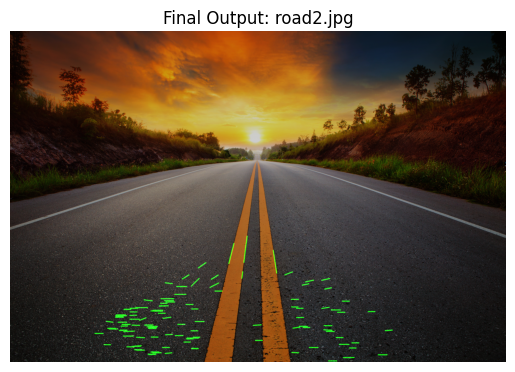

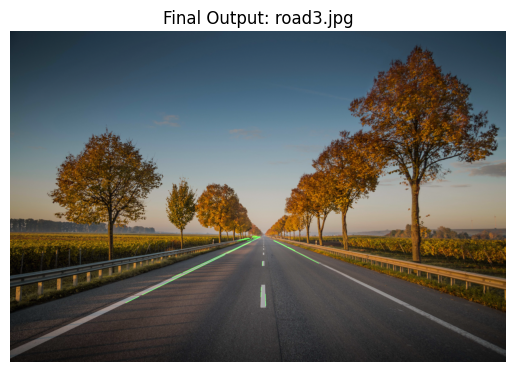

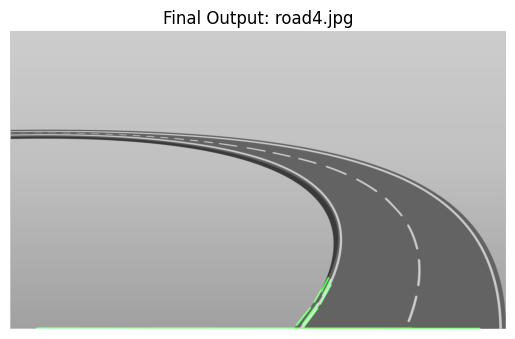

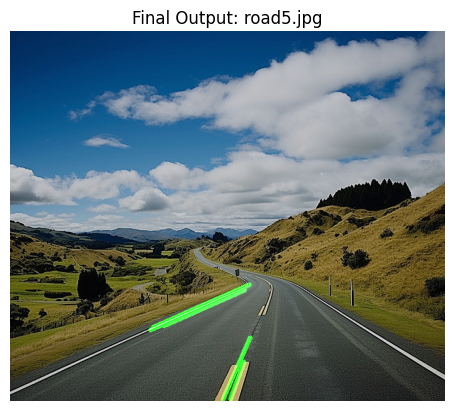

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def gaussian_blur(img, kernel_size=5):
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

def canny(img, low_threshold=50, high_threshold=150):
    return cv2.Canny(img, low_threshold, high_threshold)

def region_of_interest(img):
    height = img.shape[0]
    polygons = np.array([
        [(100, height), (img.shape[1] - 100, height), (img.shape[1] // 2, int(height * 0.6))]
    ])
    mask = np.zeros_like(img)
    cv2.fillPoly(mask, polygons, 255)
    return cv2.bitwise_and(img, mask)

def detect_lines(img):
    return cv2.HoughLinesP(img, 2, np.pi/180, 100, np.array([]), minLineLength=40, maxLineGap=5)

def draw_lines(img, lines):
    line_img = np.zeros_like(img)
    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 5)
    return cv2.addWeighted(img, 0.8, line_img, 1, 1)

# Load and process each image
image_files = ['road1.jpg', 'road2.jpg', 'road3.jpg', 'road4.jpg', 'road5.jpg']

for file in image_files:
    image = cv2.imread(file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    gray = grayscale(image)
    blur = gaussian_blur(gray)
    edges = canny(blur)
    roi = region_of_interest(edges)
    lines = detect_lines(roi)
    result = draw_lines(image, lines)

    plt.imshow(result)
    plt.title(f"Final Output: {file}")
    plt.axis("off")
    plt.show()
